# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
print("Số dòng:", df.shape[0], "| Số cột:", df.shape[1])
print("\nTên cột:", list(df.columns))
print("\nKiểu dữ liệu:")
df.info()

Số dòng: 541909 | Số cột: 8

Tên cột: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


## A.2. Missing values & Duplicate data

In [4]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "Không có missing value.")
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate theo InvoiceNo + StockCode + InvoiceDate:",
      df.duplicated(subset=['InvoiceNo', 'StockCode', 'InvoiceDate']).sum())

Missing values:
Description      1454
CustomerID     135080
dtype: int64

Duplicate rows: 5268
Duplicate theo InvoiceNo + StockCode + InvoiceDate: 10677


## A.3. Invalid values

In [15]:
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())
print("InvoiceDate in the future:", (df['InvoiceDate'] > pd.Timestamp.today()).sum())

Quantity <= 0: 10624
UnitPrice <= 0: 2517
InvoiceDate in the future: 0


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [3]:
returns = df['Quantity'] <= 0
df_clean = df.loc[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df_clean['Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['ORDER_MONTH'] = df_clean['InvoiceDate'].dt.month
df_clean['ORDER_YEAR'] = df_clean['InvoiceDate'].dt.year

print("Số dòng sau khi làm sạch:", len(df_clean))
print("Số giao dịch bị loại:", returns.sum())
df_clean[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'Sales']].head()

Số dòng sau khi làm sạch: 530104
Số giao dịch bị loại: 10624


,InvoiceNo,Description,Quantity,UnitPrice,Sales
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,WHITE METAL LANTERN,6,3.39,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [6]:
for col in ['Quantity', 'UnitPrice', 'Sales']:
    mean_, median_, mode_ = df_clean[col].mean(), df_clean[col].median(), df_clean[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")

Quantity: Mean=10.54, Median=3.00, Mode=1.00
UnitPrice: Mean=3.91, Median=2.08, Mode=1.25
Sales: Mean=20.12, Median=9.90, Mode=15.00


## Group 2 — Dispersion

In [7]:
for col in ['Quantity', 'UnitPrice', 'Sales']:
    s = df_clean[col]
    range_ = s.max() - s.min()
    variance_ = s.var()
    std_ = s.std()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    cv = std_ / s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Variance={variance_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- Quantity ---
Range=80994.00, Variance=24187.75, Std=155.52, IQR=9.00, CV=14.75
--- UnitPrice ---
Range=13541.33, Variance=1289.94, Std=35.92, IQR=2.88, CV=9.19
--- Sales ---
Range=168469.60, Variance=73092.77, Std=270.36, IQR=13.95, CV=13.44


## Group 3 — Location and Shape

--- Quantity ---
P25=1.00, P50=3.00, P75=10.00
Skewness=471.73, Kurtosis=236460.11
--- UnitPrice ---
P25=1.25, P50=2.08, P75=4.13
Skewness=206.09, Kurtosis=62482.55
--- Sales ---
P25=3.75, P50=9.90, P75=17.70
Skewness=506.70, Kurtosis=297648.85


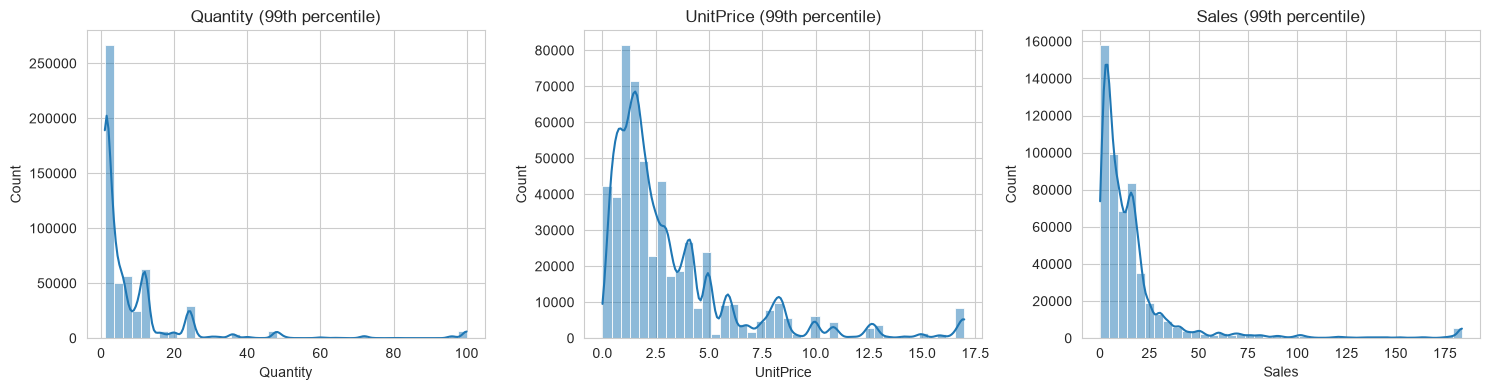

Nhận xét: Quantity, UnitPrice và Sales đều lệch phải


In [14]:
for col in ['Quantity', 'UnitPrice', 'Sales']:
    s = df_clean[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.50):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Quantity', 'UnitPrice', 'Sales']):
    sns.histplot(df_clean[col].clip(upper=df_clean[col].quantile(0.99)), bins=40, kde=True, ax=ax)
    ax.set_title(f'{col} (99th percentile)')
plt.tight_layout()
plt.show()
print("Nhận xét: Quantity, UnitPrice và Sales đều lệch phải")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

Country
United Kingdom    9025222.08
Netherlands        285446.34
EIRE               283453.96
Germany            228867.14
France             209715.11
Australia          138521.31
Spain               61577.11
Switzerland         57089.90
Belgium             41196.34
Sweden              38378.33
Name: Sales, dtype: float64

Insight: United Kingdom đóng góp 84.6% tổng doanh thu.


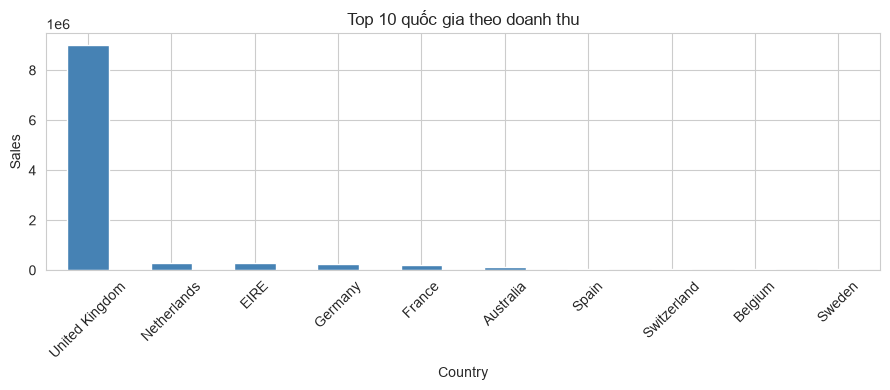

In [9]:
sales_by_country = df_clean.groupby('Country')['Sales'].sum().sort_values(ascending=False)
top_country = sales_by_country.index[0]
top_pct = sales_by_country.iloc[0] / sales_by_country.sum() * 100
print(sales_by_country.head(10).round(2))
print(f"\nInsight: {top_country} đóng góp {top_pct:.1f}% tổng doanh thu.")

fig, ax = plt.subplots(figsize=(9, 4))
sales_by_country.head(10).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 quốc gia theo doanh thu')
ax.set_ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

StockCode  Description                       
DOT        DOTCOM POSTAGE                        206248.77
22423      REGENCY CAKESTAND 3 TIER              174484.74
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER    104340.29
47566      PARTY BUNTING                          99504.33
85099B     JUMBO BAG RED RETROSPOT                94340.05
23166      MEDIUM CERAMIC TOP STORAGE JAR         81700.92
M          Manual                                 78110.27
POST       POSTAGE                                78101.88
23084      RABBIT NIGHT LIGHT                     66964.99
Name: Sales, dtype: float64

Insight: Sản phẩm có doanh thu cao nhất là mã DOT - DOTCOM POSTAGE.


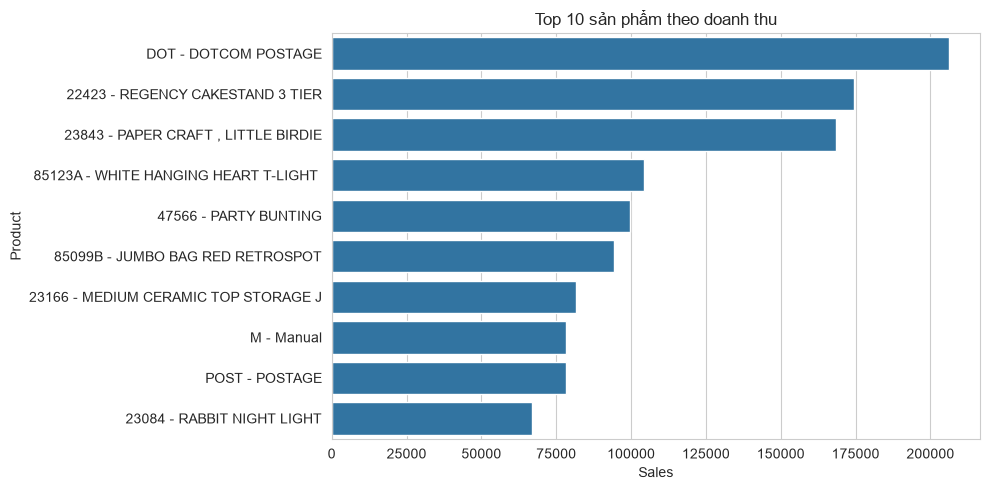

In [18]:
sales_by_product = df_clean.groupby(['StockCode', 'Description'])['Sales'].sum().sort_values(ascending=False)
print(sales_by_product.head(10).round(2))
top_product = sales_by_product.index[0]
print(f"\nInsight: Sản phẩm có doanh thu cao nhất là mã {top_product[0]} - {top_product[1]}.")

plot_data = sales_by_product.head(10).reset_index()
plot_data['Product'] = plot_data['StockCode'].astype(str) + ' - ' + plot_data['Description'].str.slice(0, 28)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_data, y='Product', x='Sales', ax=ax)
ax.set_title('Top 10 sản phẩm theo doanh thu')
plt.tight_layout()
plt.show()

## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

ORDER_MONTH
1      77.8
2      58.9
3      80.7
4      60.5
5      86.7
6      85.7
7      80.9
8      85.4
9     119.1
10    129.9
11    169.8
12    164.5
Name: Sales, dtype: float64


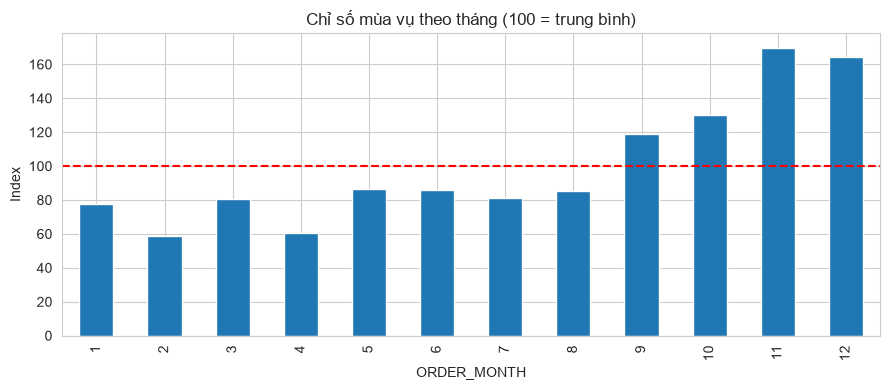

Insight: Tháng cao điểm là 11 (169.8), thấp điểm là 2 (58.9).


In [16]:
monthly_sales = df_clean.groupby('ORDER_MONTH')['Sales'].sum()
seasonality_index = (monthly_sales / monthly_sales.mean() * 100).round(1)
print(seasonality_index)

fig, ax = plt.subplots(figsize=(9, 4))
seasonality_index.plot(kind='bar', ax=ax)
ax.axhline(100, color='red', linestyle='--')
ax.set_title('Chỉ số mùa vụ theo tháng (100 = trung bình)')
ax.set_ylabel('Index')
plt.tight_layout()
plt.show()

print(f"Insight: Tháng cao điểm là {seasonality_index.idxmax()} ({seasonality_index.max():.1f}), thấp điểm là {seasonality_index.idxmin()} ({seasonality_index.min():.1f}).")

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

                mean   median  count
Country                             
Singapore    3039.90  2118.74      7
Netherlands  3036.66   806.88     94
Australia    2430.20   429.60     57
Japan        1969.28  1607.04     19
Lebanon      1693.88  1693.88      1
Hong Kong    1426.53  1539.64     11
Brazil       1143.60  1143.60      1
Sweden       1066.06   372.18     36
Switzerland  1057.22   625.96     54
Denmark      1053.07   515.10     18
Israel       1016.91   401.78      8
Norway       1004.60   631.27     36
RSA          1002.31  1002.31      1
EIRE          984.22   651.72    288
Greece        952.10   609.74      5


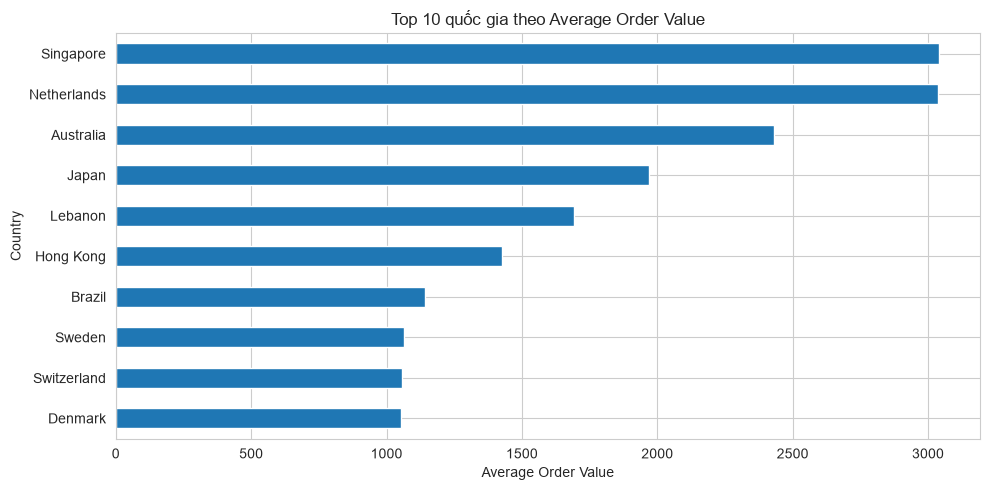

Insight: Quốc gia có AOV trung bình cao nhất là Singapore (3039.90).


In [17]:
order_sales = df_clean.groupby(['Country', 'InvoiceNo'])['Sales'].sum()
aov_by_country = order_sales.groupby(level='Country').agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print(aov_by_country.head(15).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
aov_by_country.head(10)['mean'].sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 quốc gia theo Average Order Value')
ax.set_xlabel('Average Order Value')
plt.tight_layout()
plt.show()
print(f"Insight: Quốc gia có AOV trung bình cao nhất là {aov_by_country.index[0]} ({aov_by_country.iloc[0]['mean']:.2f}).")

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.